In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  family_size  891 non-null    int64   
dtypes: bool(2), category(2), float64(2), int64(5), object(5)
memory usage: 87.6+ KB


# Feature Enginnering

In [32]:
df['family_size'] = df['sibsp'] + df['parch']

In [37]:
df['deck'] = df['deck'].cat.add_categories('U')
df['deck'] = df['deck'].fillna('U')

# Preparing The Data

In [40]:
df_new = df.drop(columns=['sibsp','parch','alone','who','alive','embark_town'])
df_new

,survived,pclass,sex,age,fare,embarked,class,adult_male,deck,family_size
0,0,3,male,22.0,7.2500,S,Third,True,U,1
1,1,1,female,38.0,71.2833,C,First,False,C,1
2,1,3,female,26.0,7.9250,S,Third,False,U,0
3,1,1,female,35.0,53.1000,S,First,False,C,1
4,0,3,male,35.0,8.0500,S,Third,True,U,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,Second,True,U,0
887,1,1,female,19.0,30.0000,S,First,False,B,0
888,0,3,female,NaN,23.4500,S,Third,False,U,3
889,1,1,male,26.0,30.0000,C,First,True,C,0


In [41]:
X = df_new.drop(columns='survived')
y = df_new['survived']

In [42]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       891 non-null    int64   
 1   sex          891 non-null    object  
 2   age          714 non-null    float64 
 3   fare         891 non-null    float64 
 4   embarked     889 non-null    object  
 5   class        891 non-null    category
 6   adult_male   891 non-null    bool    
 7   deck         891 non-null    category
 8   family_size  891 non-null    int64   
dtypes: bool(1), category(2), float64(2), int64(2), object(2)
memory usage: 45.0+ KB


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import  train_test_split
from sklearn.impute import  SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [45]:
X_train

,pclass,sex,age,fare,embarked,class,adult_male,deck,family_size
331,1,male,45.5,28.5000,S,First,True,C,0
733,2,male,23.0,13.0000,S,Second,True,U,0
382,3,male,32.0,7.9250,S,Third,True,U,0
704,3,male,26.0,7.8542,S,Third,True,U,1
813,3,female,6.0,31.2750,S,Third,False,U,6
...,...,...,...,...,...,...,...,...,...
106,3,female,21.0,7.6500,S,Third,False,U,0
270,1,male,NaN,31.0000,S,First,True,U,0
860,3,male,41.0,14.1083,S,Third,True,U,2
435,1,female,14.0,120.0000,S,First,False,B,3


In [9]:
embarked_pipe = Pipeline(
    [
        ('embarked_imputer', SimpleImputer(strategy='most_frequent')),
        ('embarked_encode', OrdinalEncoder())
    ]
)

In [53]:
preprocess = ColumnTransformer([
    ('pclass_encode', OrdinalEncoder(), ['pclass']),
    ('sex_encode', OneHotEncoder(sparse_output=False, drop='first'), ['sex']),
    ('age_impute', SimpleImputer(strategy='mean'), ['age']),
    ('embarked_pipe', embarked_pipe, ['embarked']),
    ('class_encode', OrdinalEncoder(), ['class']),
    ('adult_encode', OneHotEncoder(sparse_output=False, drop='first'), ['adult_male']),
    ('deck_encode', OrdinalEncoder(), ['deck'])
], remainder='passthrough')

In [55]:
main_pipe = Pipeline([
    ('preprocessing',preprocess),
    ('scaling',StandardScaler())
]).set_output(transform='pandas')

In [56]:
main_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('scaling', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pclass_encode', ...), ('sex_encode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

In [57]:
X_train_processed = main_pipe.fit_transform(X_train)

In [58]:
X_test_processed = main_pipe.transform(X_test)

# Model Training & Evaluation

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import  DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  accuracy_score, classification_report

In [60]:
RF = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

LR = LogisticRegression()

DT = DecisionTreeClassifier(random_state=42)

In [61]:
RF.fit(X_train_processed, y_train)
LR.fit(X_train_processed, y_train)
DT.fit(X_train_processed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [62]:
Logistic_prediction = LR.predict(X_test_processed)
Decision_prediction = DT.predict(X_test_processed)
Random_prediction = RF.predict(X_test_processed)

In [63]:
print('accuracy of Logistic Regression Model:',accuracy_score(y_test, Logistic_prediction)*(100))
print('accuracy of Decision Tree Model:',accuracy_score(y_test, Decision_prediction)*(100))
print('accuracy of Random Forest Model:',accuracy_score(y_test, Random_prediction)*(100))

accuracy of Logistic Regression Model: 81.56424581005587
accuracy of Decision Tree Model: 75.97765363128491
accuracy of Random Forest Model: 79.88826815642457


In [64]:
print('Classification Report of Logistic Regression Model:','\n',classification_report(y_test, Logistic_prediction))

Classification Report of Logistic Regression Model: 
               precision    recall  f1-score   support

           0       0.83      0.86      0.85       105
           1       0.79      0.76      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.81      0.82      0.82       179



In [65]:
print('Classification Report of Decision Tree Model:','\n',classification_report(y_test, Decision_prediction))

Classification Report of Decision Tree Model: 
               precision    recall  f1-score   support

           0       0.80      0.78      0.79       105
           1       0.70      0.73      0.72        74

    accuracy                           0.76       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.76      0.76      0.76       179



In [66]:
print('Classification Report of Random Forest Model:','\n',classification_report(y_test, Random_prediction))

Classification Report of Random Forest Model: 
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [74]:
from sklearn.metrics import roc_curve, roc_auc_score

In [72]:
y_prob_LR = LR.predict_proba(X_test_processed)[:,1]
y_prob_DT = DT.predict_proba(X_test_processed)[:,1]
y_prob_RF = RF.predict_proba(X_test_processed)[:,1]

In [75]:
auc_score_LR = roc_auc_score(y_test, y_prob_LR)
auc_score_DT = roc_auc_score(y_test, y_prob_DT)
auc_score_RF = roc_auc_score(y_test, y_prob_RF)

In [76]:
print(f"AUC Score of LR: {auc_score_LR:.4f}")
print(f"AUC Score of DT: {auc_score_DT:.4f}")
print(f"AUC Score of RF: {auc_score_RF:.4f}")

AUC Score of LR: 0.8792
AUC Score of DT: 0.7600
AUC Score of RF: 0.8960


In [77]:
fpr_LR, tpr_LR, threshold_LR = roc_curve(y_test, y_prob_LR)
fpr_DT, tpr_DT, threshold_DT = roc_curve(y_test, y_prob_DT)
fpr_RF, tpr_RF, threshold_RF = roc_curve(y_test, y_prob_RF)

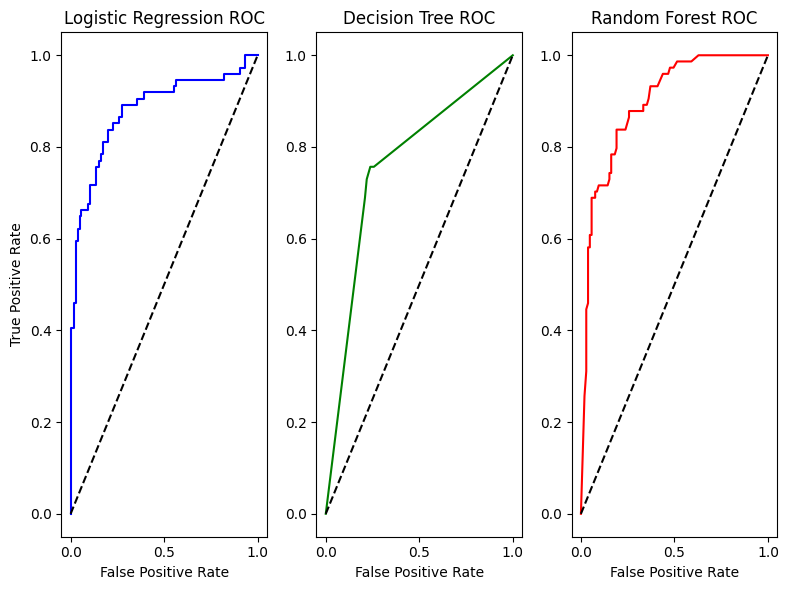

In [79]:
fig, ax = plt.subplots(1,3,figsize=(8,6))

ax[0].plot(fpr_LR, tpr_LR, label='LR', color='blue')
ax[0].plot([0, 1], [0, 1], 'k--') # Diagonal dashed line
ax[0].set_title('Logistic Regression ROC')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')

ax[1].plot(fpr_DT, tpr_DT, label='DT', color='green')
ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_title('Decision Tree ROC')
ax[1].set_xlabel('False Positive Rate')

ax[2].plot(fpr_RF, tpr_RF, label='RF', color='red')
ax[2].plot([0, 1], [0, 1], 'k--')
ax[2].set_title('Random Forest ROC')
ax[2].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()